            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

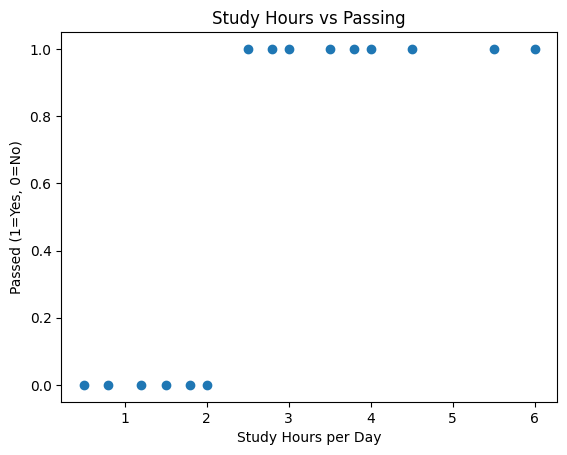

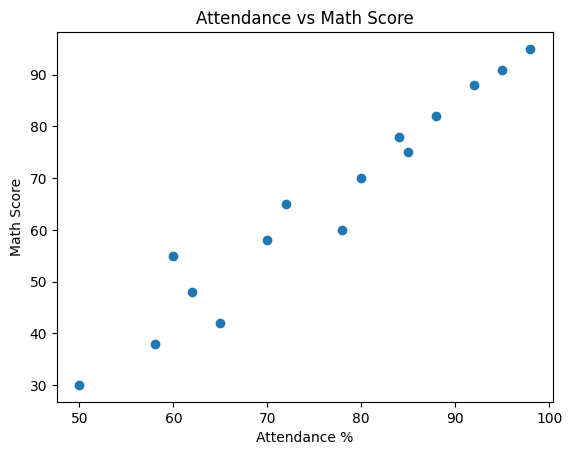

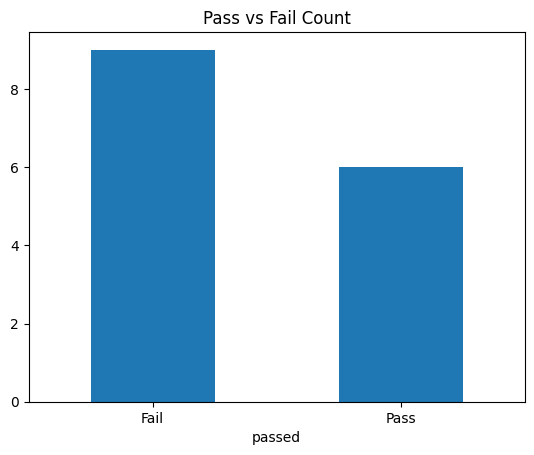

Model Accuracy: 1.0
Prediction (1=Pass, 0=Fail): 1


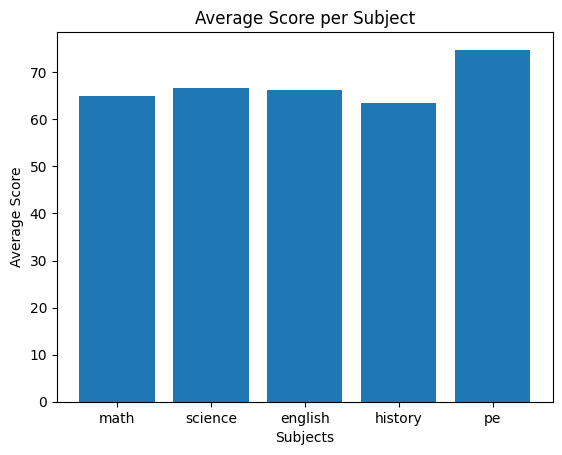

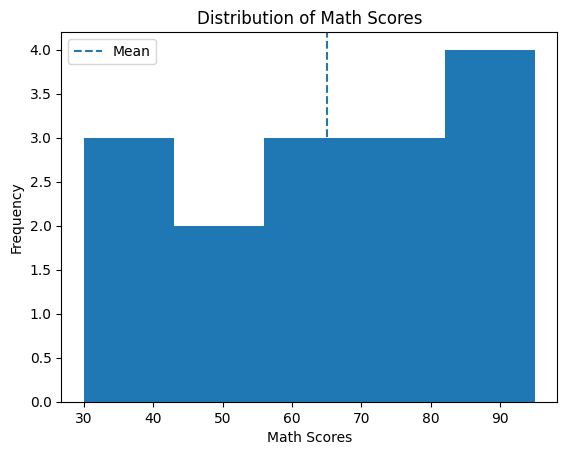

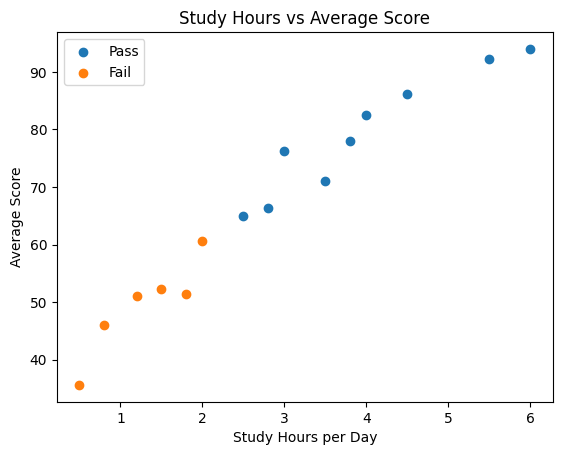

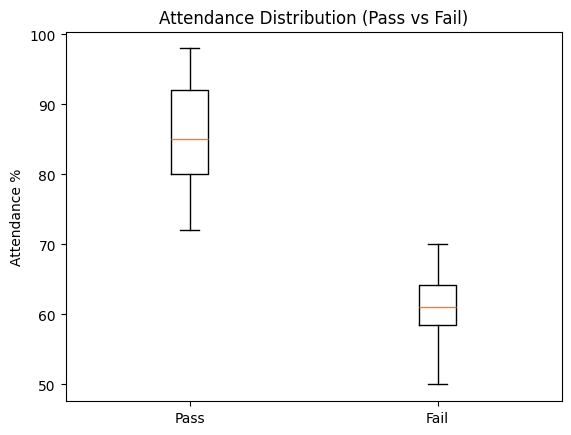

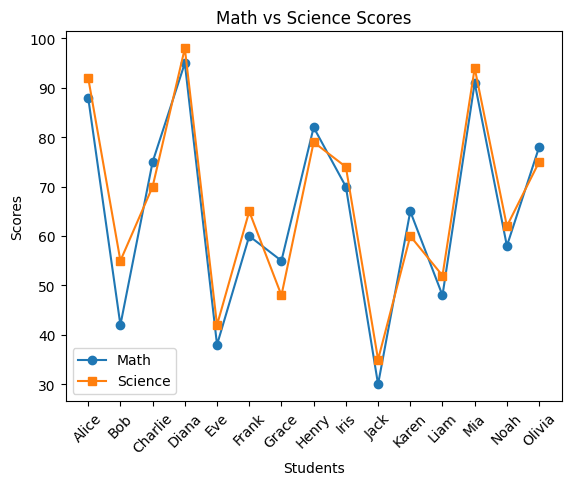

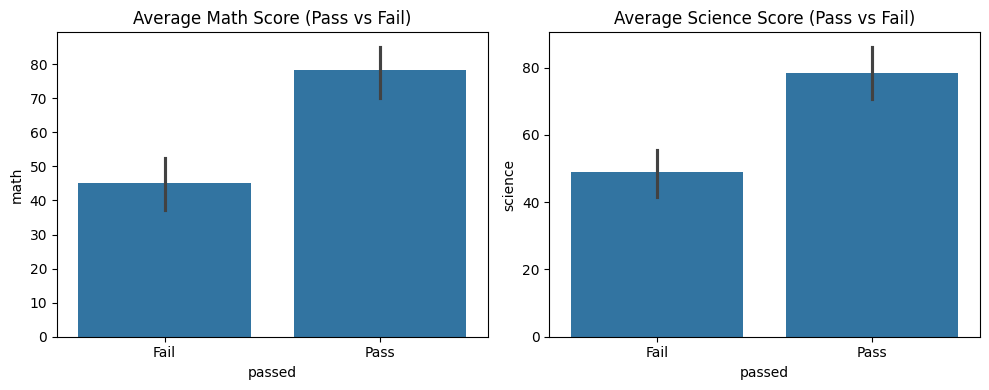

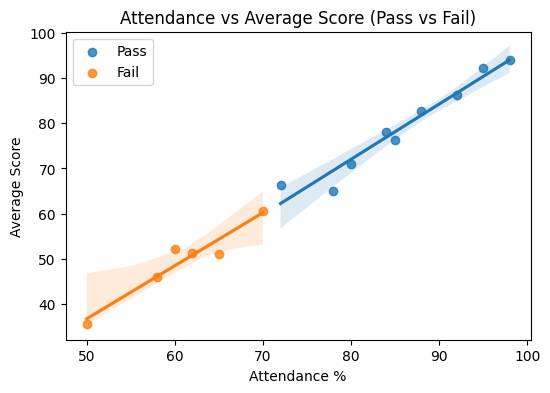

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "name": ["Alice","Bob","Charlie","Diana","Eve","Frank","Grace","Henry","Iris","Jack","Karen","Liam","Mia","Noah","Olivia"],
    "math": [88,42,75,95,38,60,55,82,70,30,65,48,91,58,78],
    "science": [92,55,70,98,42,65,48,79,74,35,60,52,94,62,75],
    "english": [76,48,80,91,50,72,44,85,68,40,70,44,88,55,82],
    "history": [80,50,68,89,45,58,52,77,65,28,62,55,92,60,70],
    "pe": [95,60,88,97,55,70,62,90,78,45,75,58,96,68,85],
    "attendance_pct": [92,65,85,98,58,78,60,88,80,50,72,62,95,70,84],
    "study_hours_per_day": [4.5,1.2,3.0,6.0,0.8,2.5,1.5,4.0,3.5,0.5,2.8,1.8,5.5,2.0,3.8],
    "passed": [1,0,1,1,0,1,0,1,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)
df.head()

print(df.describe())

print("\nPass/Fail count:")
print(df["passed"].value_counts())

plt.scatter(df["study_hours_per_day"], df["passed"])
plt.xlabel("Study Hours per Day")
plt.ylabel("Passed (1=Yes, 0=No)")
plt.title("Study Hours vs Passing")
plt.show()

plt.scatter(df["attendance_pct"], df["math"])
plt.xlabel("Attendance %")
plt.ylabel("Math Score")
plt.title("Attendance vs Math Score")
plt.show()

df["passed"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail Count")
plt.xticks([0,1], ["Fail", "Pass"], rotation=0)
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[["math", "science", "english", "history", "attendance_pct", "study_hours_per_day"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

sample = pd.DataFrame([[80, 85, 78, 75, 90, 4]],
                      columns=["math", "science", "english", "history", "attendance_pct", "study_hours_per_day"])

prediction = model.predict(sample)

print("Prediction (1=Pass, 0=Fail):", prediction[0])


# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -----------------------------
# 1. BAR CHART
# -----------------------------
avg_scores = df[subject_cols].mean()

plt.bar(avg_scores.index, avg_scores.values)
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.title("Average Score per Subject")

plt.savefig("plot1_bar.png")
plt.show()

# -----------------------------
# 2. HISTOGRAM
# -----------------------------
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label='Mean')

plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.title("Distribution of Math Scores")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

# -----------------------------
# 3. SCATTER PLOT
# -----------------------------
passed_df = df[df['passed'] == 1]
failed_df = df[df['passed'] == 0]

plt.scatter(passed_df['study_hours_per_day'], passed_df['avg_score'], label='Pass')
plt.scatter(failed_df['study_hours_per_day'], failed_df['avg_score'], label='Fail')

plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.title("Study Hours vs Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

# -----------------------------
# 4. BOX PLOT
# -----------------------------
pass_attendance = df[df['passed'] == 1]['attendance_pct']
fail_attendance = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.ylabel("Attendance %")
plt.title("Attendance Distribution (Pass vs Fail)")

plt.savefig("plot4_box.png")
plt.show()

# -----------------------------
# 5. LINE PLOT
# -----------------------------
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.xlabel("Students")
plt.ylabel("Scores")
plt.title("Math vs Science Scores")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


import seaborn as sns

# -----------------------------
# 1. BAR PLOTS (Math & Science vs Pass/Fail)
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Fail', 'Pass'])

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# -----------------------------
# 2. SCATTER PLOT WITH REGRESSION
# -----------------------------
plt.figure(figsize=(6, 4))

sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# -----------------------------
# 3. COMMENT (REQUIRED BY QUESTION)
# -----------------------------
# Seaborn made plotting easier compared to Matplotlib because it directly works with DataFrames
# and automatically handles grouping and aesthetics. Matplotlib required more manual coding
# for styling and grouping, whereas Seaborn produced cleaner and more informative visuals with less effort.